In [6]:
# libraries for data manipulation
import numpy as np
import pandas as pd
from sklearn import datasets

# libraries for visualization
from plotnine import *
import matplotlib.pyplot as plt

# helper functions
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score,accuracy_score,confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.pipeline import Pipeline


# support vector classifier (used for support vector machines and maximal margin classifiers as well)
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')


Let's first create a data set that's linearly separable with 2 classes. We will use the make_blobs function.

In [7]:
# cluster_std is how far the data points spread out from the center
X, y = datasets.make_blobs(
    n_samples=50, centers=2, cluster_std=1, random_state=42
)

Let's convert our arrays into a single dataframe for visualization

In [8]:
df = pd.DataFrame({'x1':X[:,0],'x2':X[:,1],'label':y})

We will follow the usual modeling process:
- Visualize and explore data
- Initialize model 
- Fit model with training data
- Assess model performance

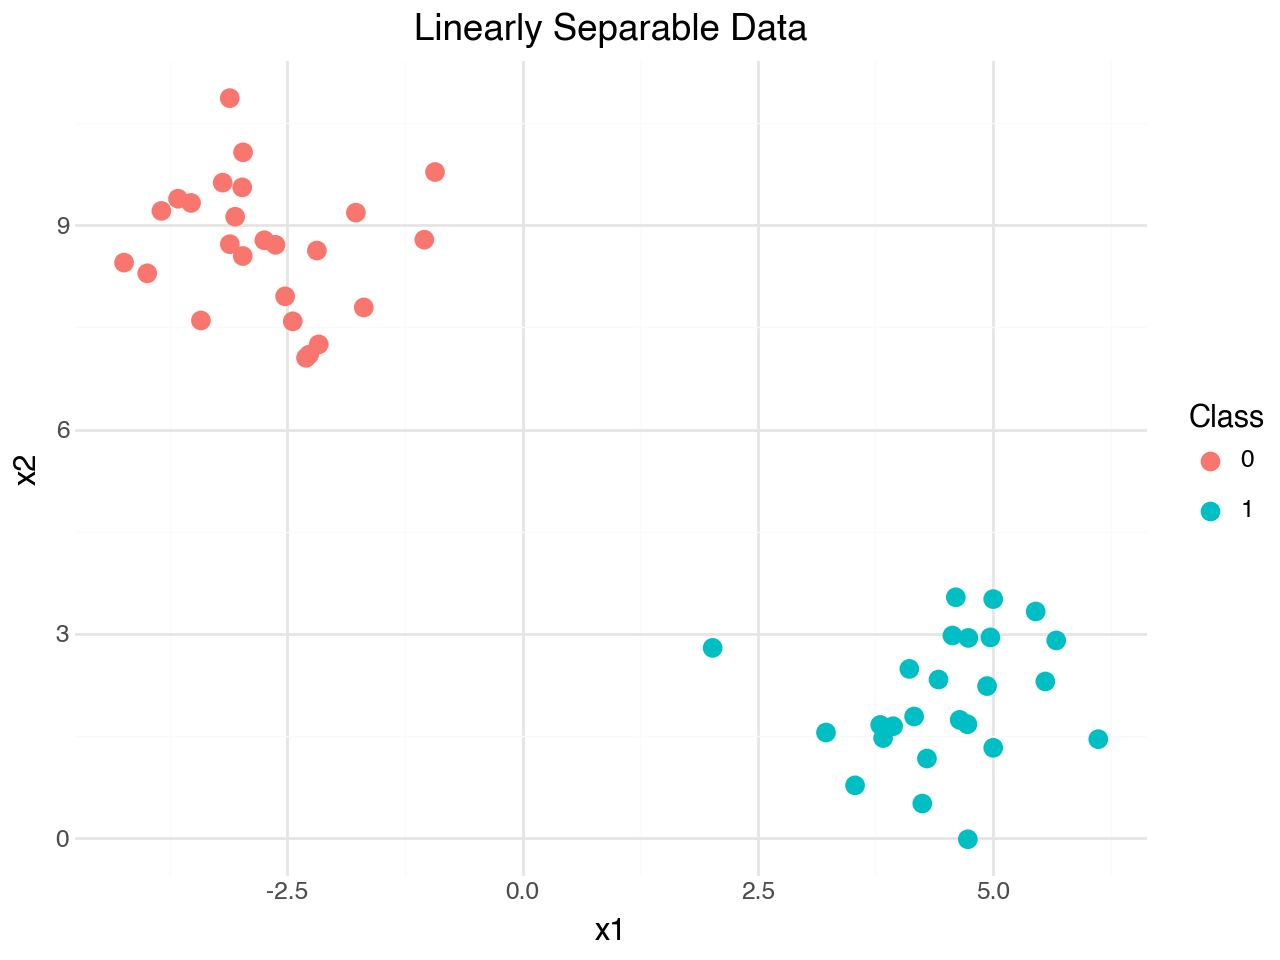

In [86]:
# Visualize data
(
    ggplot(df, aes("x1", "x2", color="factor(label)")) +
    geom_point(size=3) +
    theme_minimal() +
    labs(title="Linearly Separable Data", color="Class")
)

Maximal Marginal Classifiers are not available in scikit-learn. We will use SVC (Support Vector Classifier) function call to imitate a Hard-Margin Classifier. 

In [87]:
# initialize hard-margin Maximal Marginal Classifier
# we will do so by making C be a large value. Large C = model is strict and penalizes misclassification severely.
mmc = SVC(kernel="linear",C=1e6)

In [88]:
# fit model
mmc.fit(X,y)

,C,1000000.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
# this function is designed to visualize the hyperplane in 2D

def show_hyperplane(model,X,data):
  # generate grid
  xx, yy = np.meshgrid(
      np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
      np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200)
  )
  # for each x,y combination, predict the class
  Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

  # create dataframe for grid
  df_grid = pd.DataFrame(dict(
      x1=xx.ravel(),
      x2=yy.ravel(),
      decision=Z.ravel(),
      class_pred=model.predict(np.c_[xx.ravel(), yy.ravel()])
  ))

  # create plot using grid
  p = (
      ggplot(data, aes("x1", "x2")) +
      geom_tile(df_grid, aes("x1", "x2", fill="factor(class_pred)"), alpha=0.2) +
      geom_point(aes(color="factor(label)"), size=3) +
      geom_point(pd.DataFrame(model.support_vectors_, columns=["x1","x2"]),
                aes("x1", "x2"), shape="o", size=5, fill="none", color="black") +
      theme_538() +
      labs(title="Hyperplane Based Decision Boundary",
          color="True Class", fill="Predicted Class")
  )

  return p



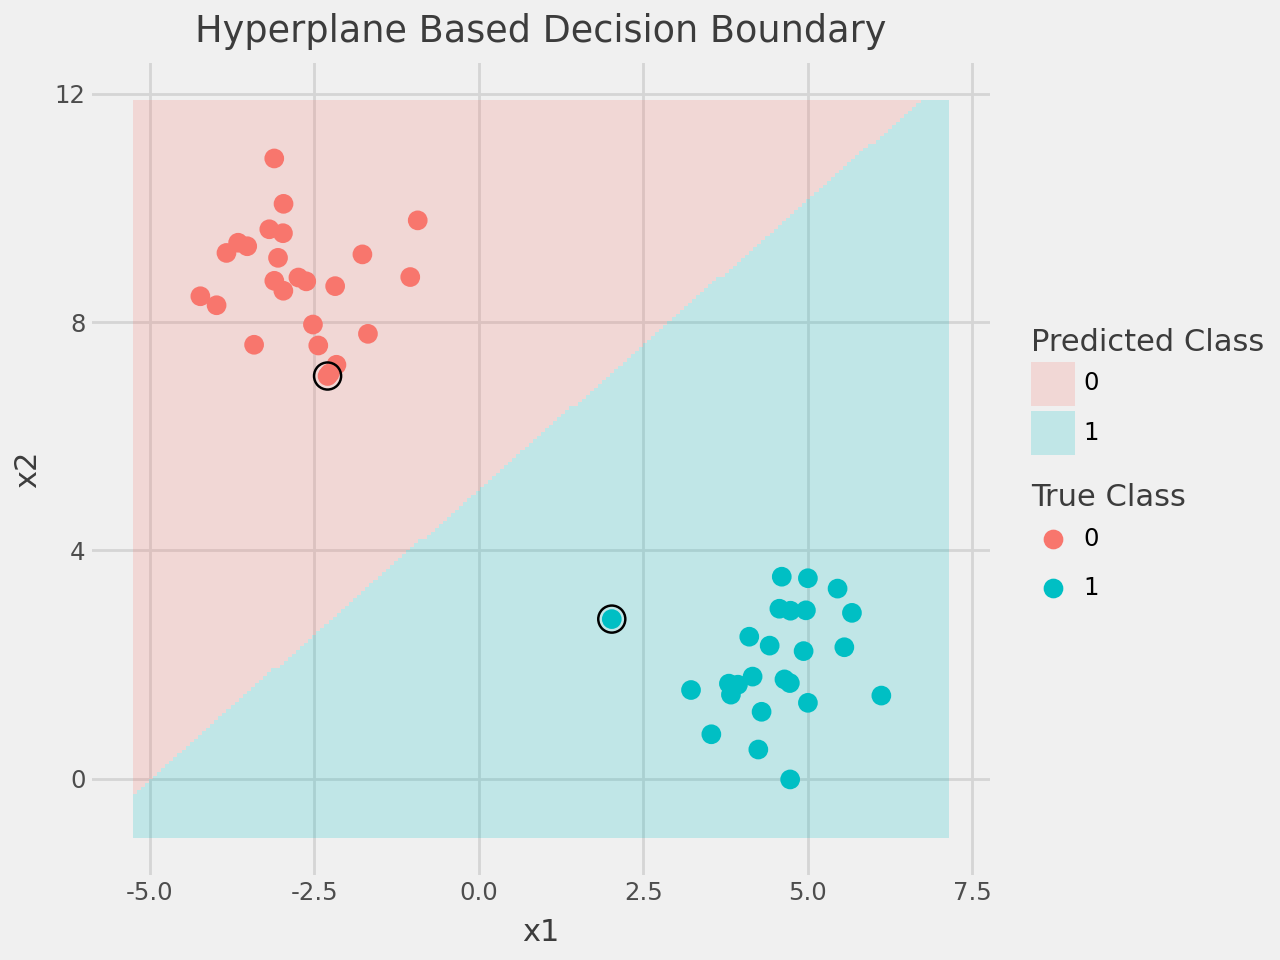

In [90]:
show_hyperplane(mmc,X,df)

Let's try again but this time with a more complex data set where the classes are not linearly separable

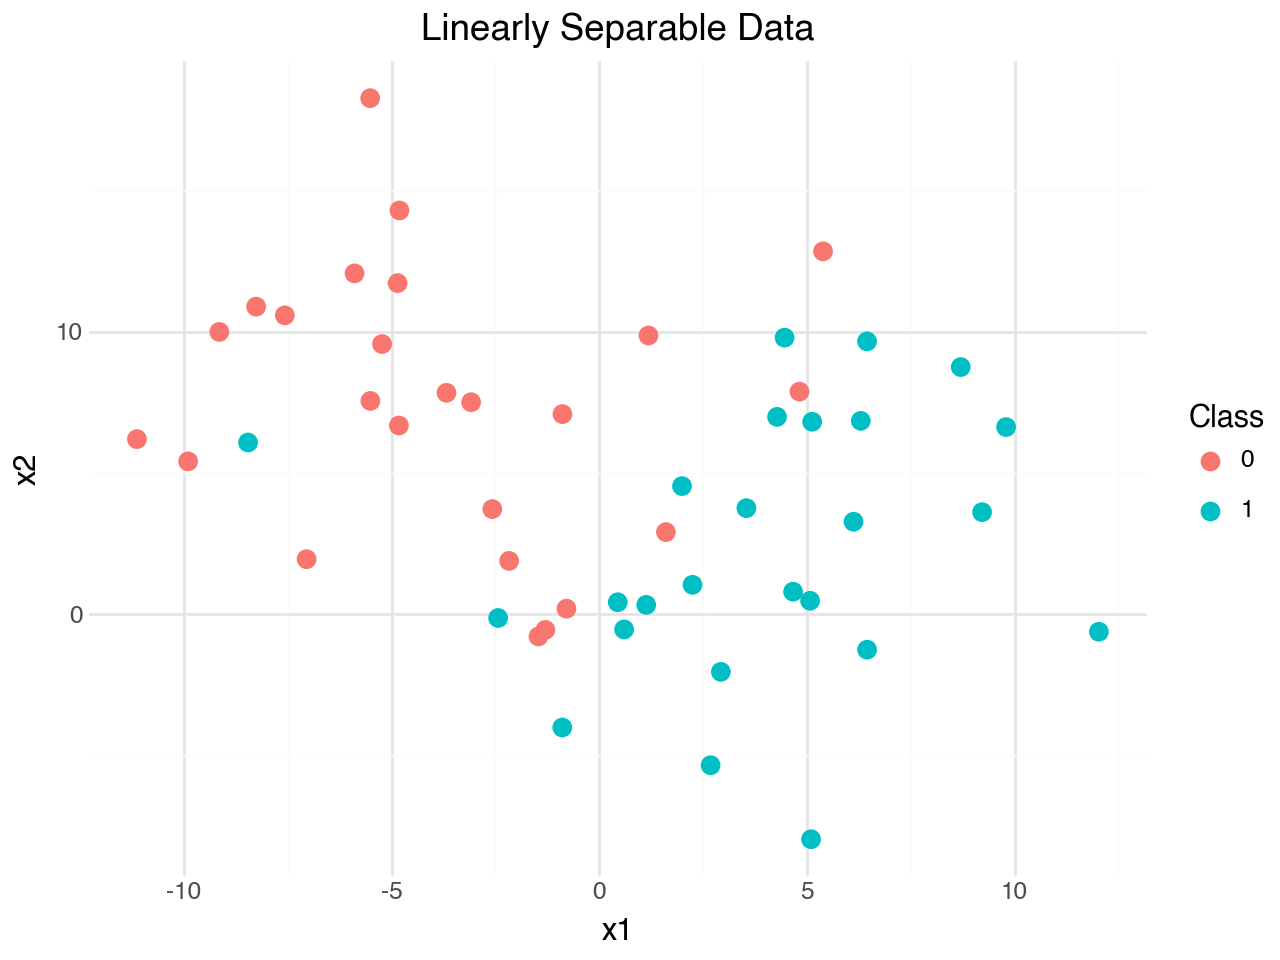

In [91]:
# prepare data
X, y = datasets.make_blobs(
    n_samples=50, centers=2, cluster_std=5, random_state=42
)

df = pd.DataFrame({'x1':X[:,0],'x2':X[:,1],'label':y})

# visualize data
(
    ggplot(df, aes("x1", "x2", color="factor(label)")) +
    geom_point(size=3) +
    theme_minimal() +
    labs(title="Linearly Separable Data", color="Class")
)

Training Accuracy: 0.825
Testing Accuracy: 0.9
Test AUC score: 1.0


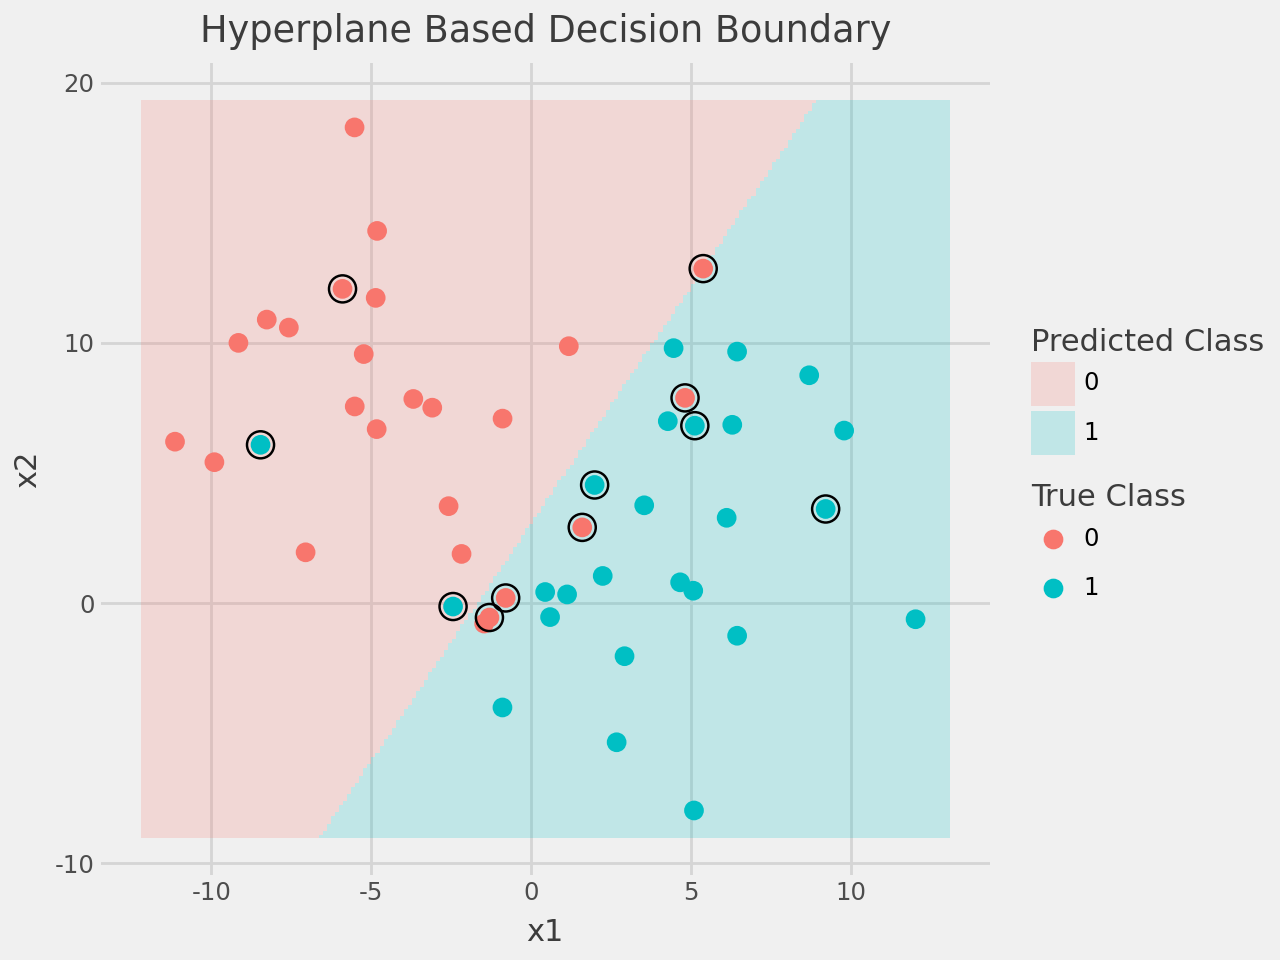

In [ ]:
# initialize model
svc = SVC(kernel="linear",C=1e6)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svc.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svc.score(X_train,y_train))
print("Testing Accuracy:",svc.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svc,X,df)

We can make C to be smaller. This will allow for more misclassifications at a low cost, resulting in a more generalized model. 

Training Accuracy: 0.85
Testing Accuracy: 0.9
Test AUC score: 1.0


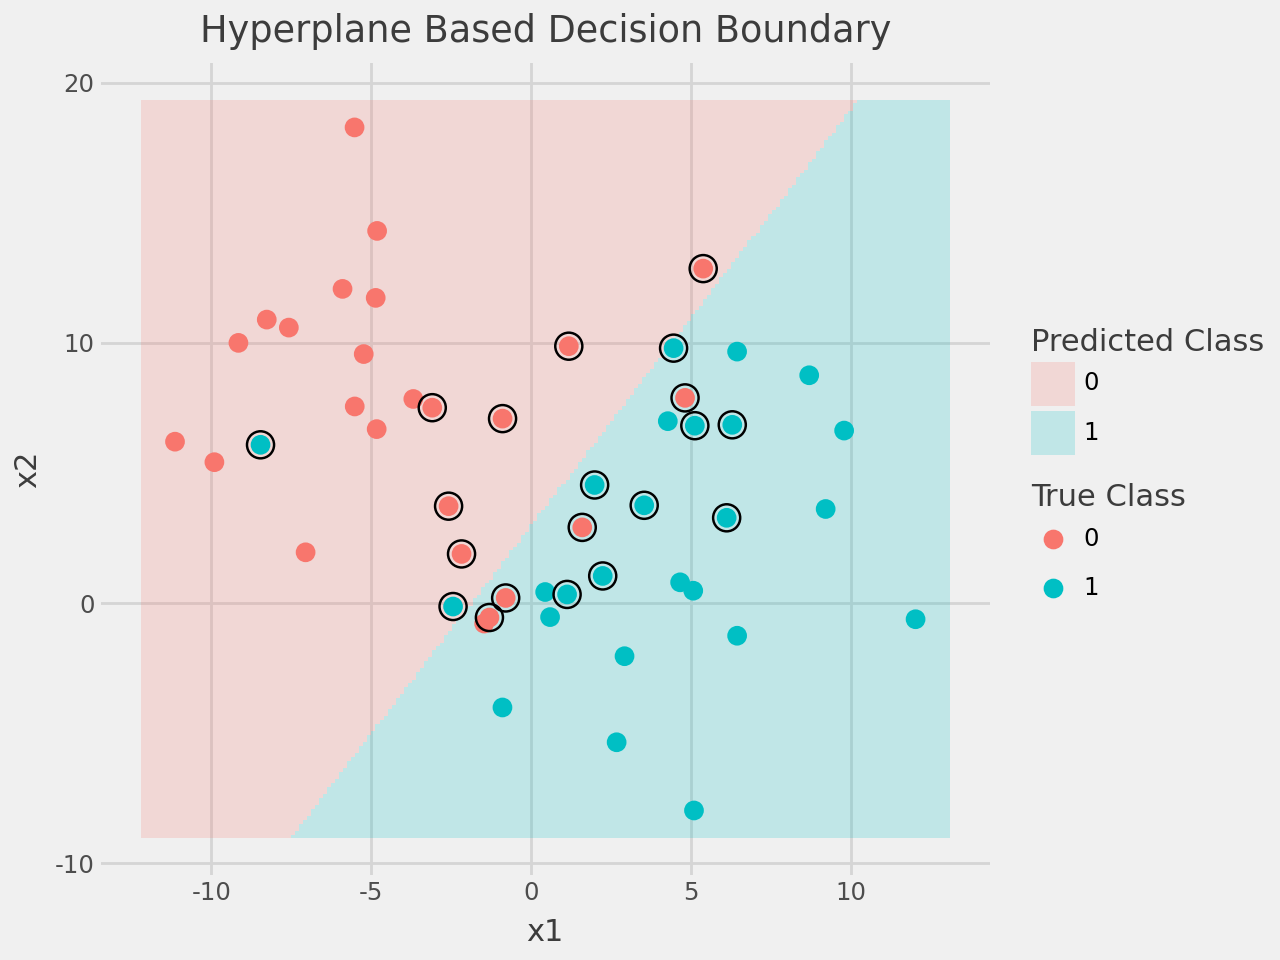

In [94]:
# initialize model
svc = SVC(kernel="linear",C=0.01)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svc.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svc.score(X_train,y_train))
print("Testing Accuracy:",svc.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svc,X,df)

Let's now try a quadratic polynomial Support Vector Machine

Training Accuracy: 0.75
Testing Accuracy: 0.9
Test AUC score: 0.761904761904762


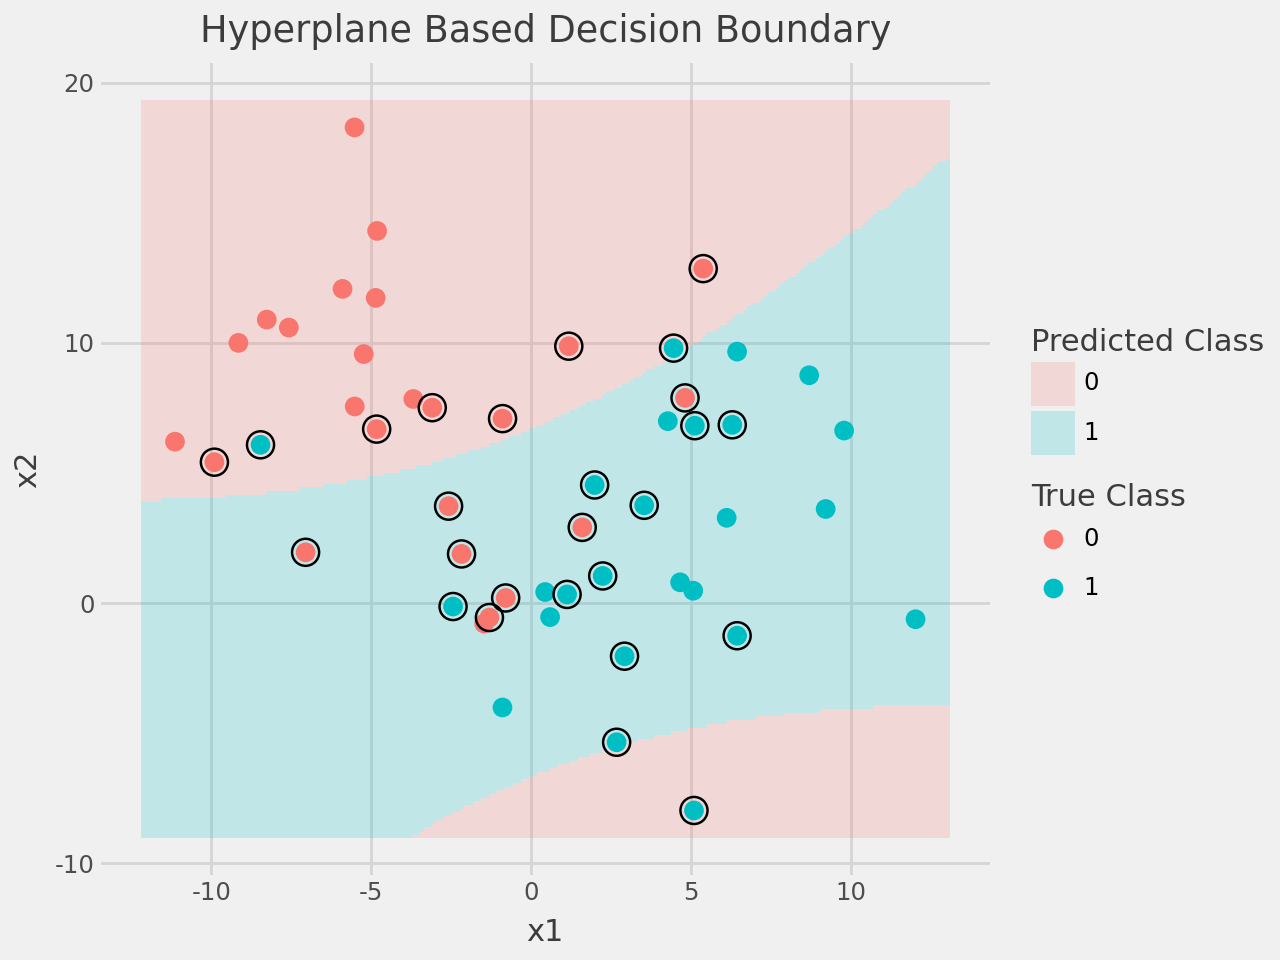

In [95]:
# initialize model
svc = SVC(kernel="poly",degree=2,C=1)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svc.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svc.score(X_train,y_train))
print("Testing Accuracy:",svc.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svc,X,df)

Try a cubic polynomial SVM

Training Accuracy: 0.8
Testing Accuracy: 0.9
Test AUC score: 1.0


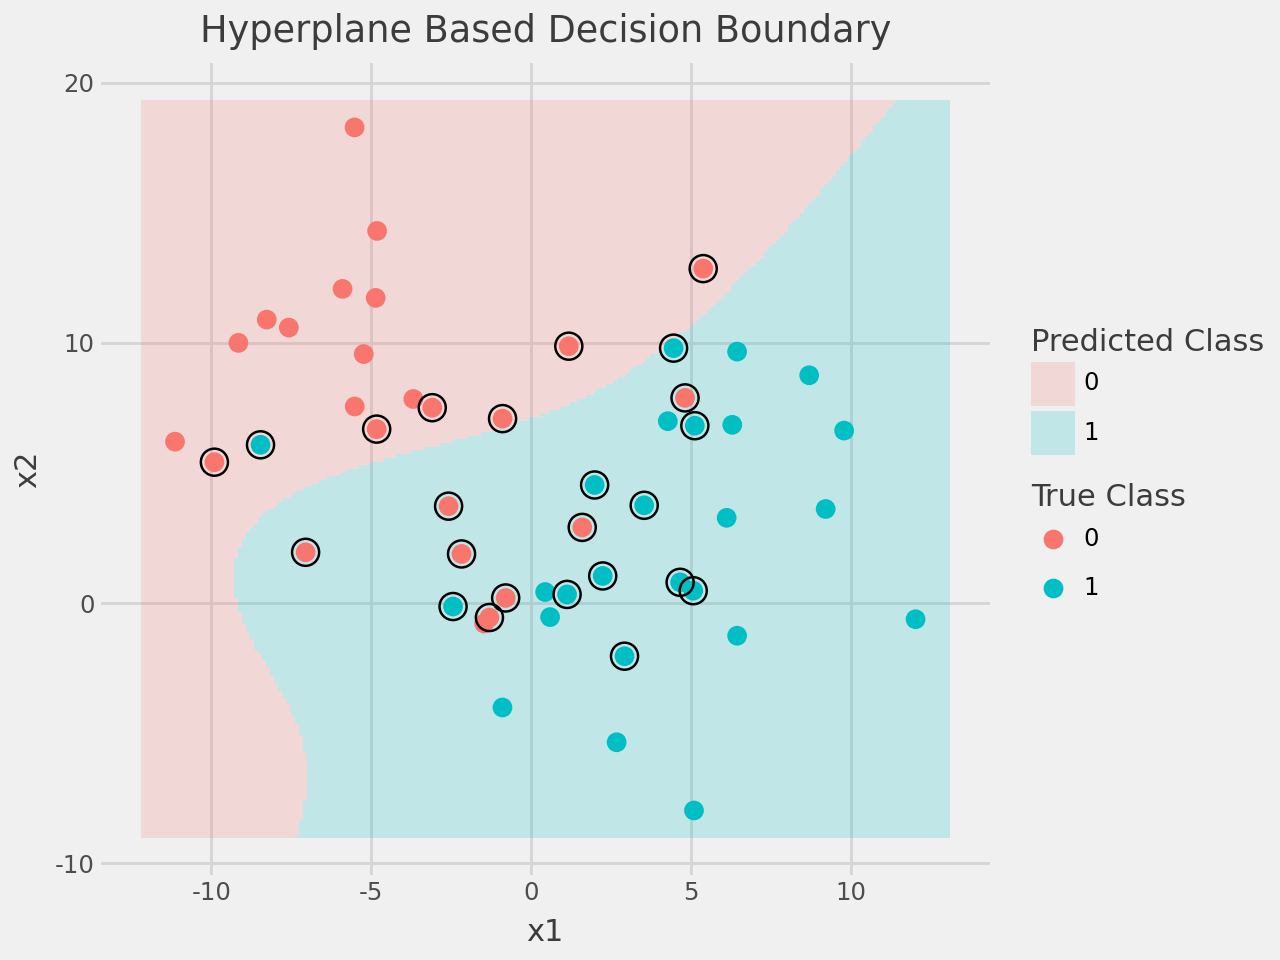

In [96]:
# initialize model
svc = SVC(kernel="poly",degree=3,C=1)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svc.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svc.score(X_train,y_train))
print("Testing Accuracy:",svc.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svc,X,df)

Next, let's look at a dataset where a polynomial SVM may not be applicable

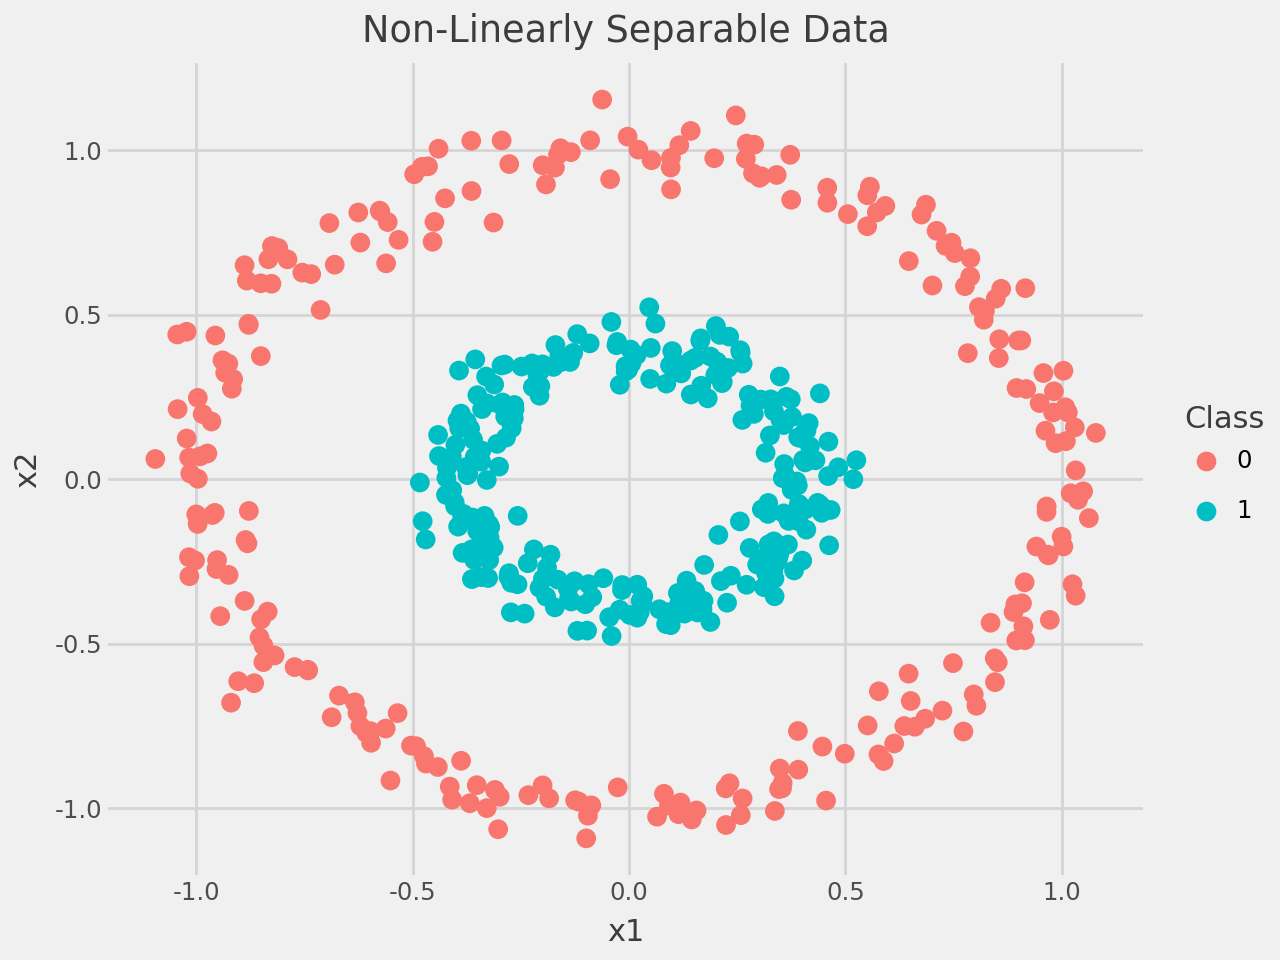

In [12]:
# prepare data
X, y = datasets.make_circles(n_samples=500, factor=0.4, noise=0.05, random_state=42)

df = pd.DataFrame({'x1':X[:,0],'x2':X[:,1],'label':y})

# visualize data
(
    ggplot(df, aes("x1", "x2", color="factor(label)")) +
    geom_point(size=3) +
    theme_538() +
    labs(title="Non-Linearly Separable Data", color="Class")
)

Try a 5-degree polynomial SVM on this dataset

Training Accuracy: 0.5175
Testing Accuracy: 0.43
Test AUC score: 0.4814361485108119


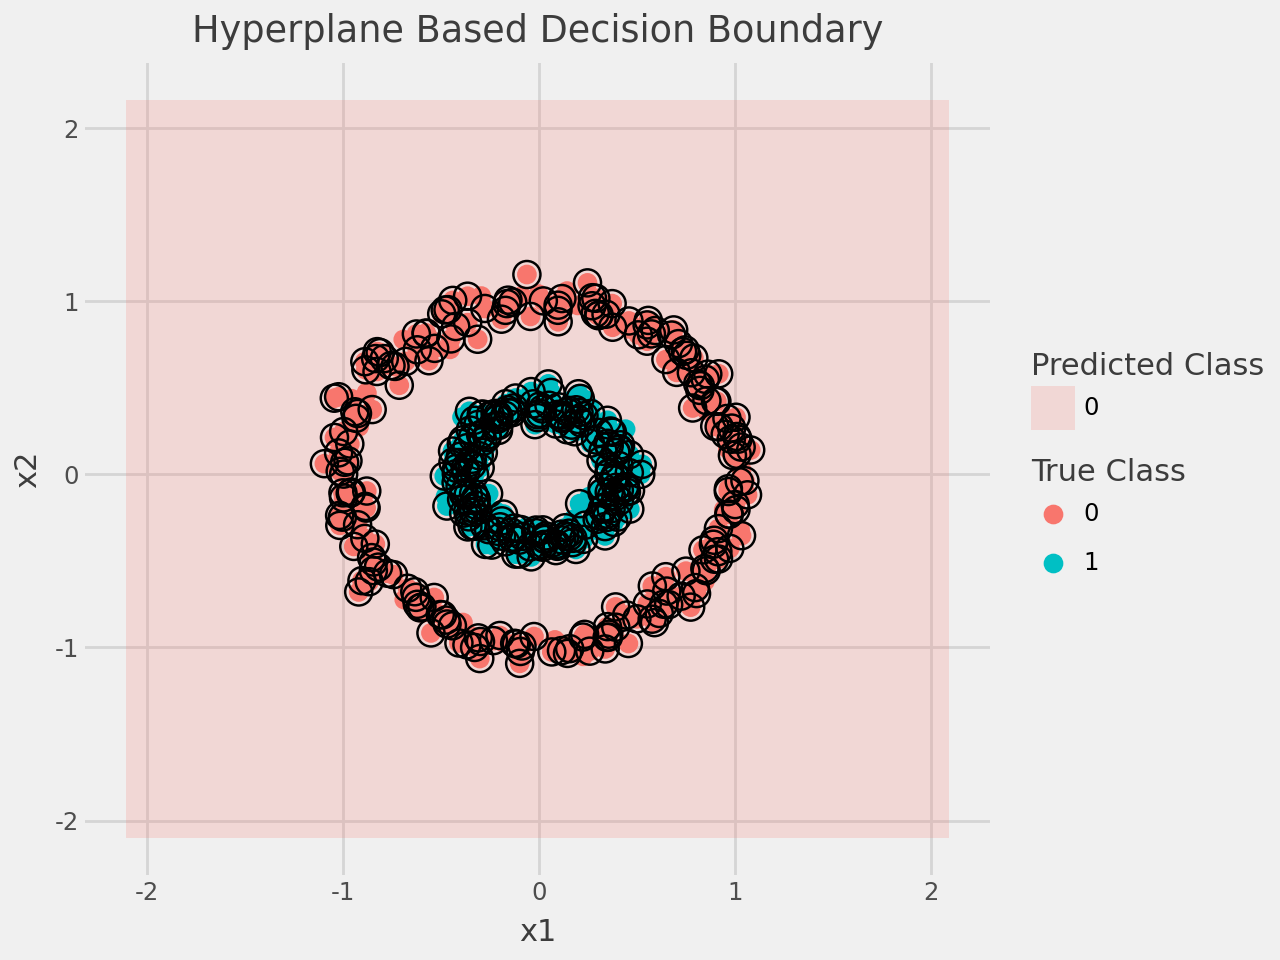

In [98]:
# initialize model
svc = SVC(kernel="poly",degree=5,C=1)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svc.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svc.score(X_train,y_train))
print("Testing Accuracy:",svc.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svc.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svc,X,df)

Let's now use a Radial Basis Function SVM. 

The gamma parameter controls the effect of higher dimensional terms. 

A low gamma value zeroes out the influence of higher dimensional terms, forcing the model to act like a simple linear model. 

A high gamma value will amplify the weights of these higher dimensional terms. Beware of overfitting here!

Training Accuracy: 1.0
Testing Accuracy: 1.0
Test AUC score: 1.0


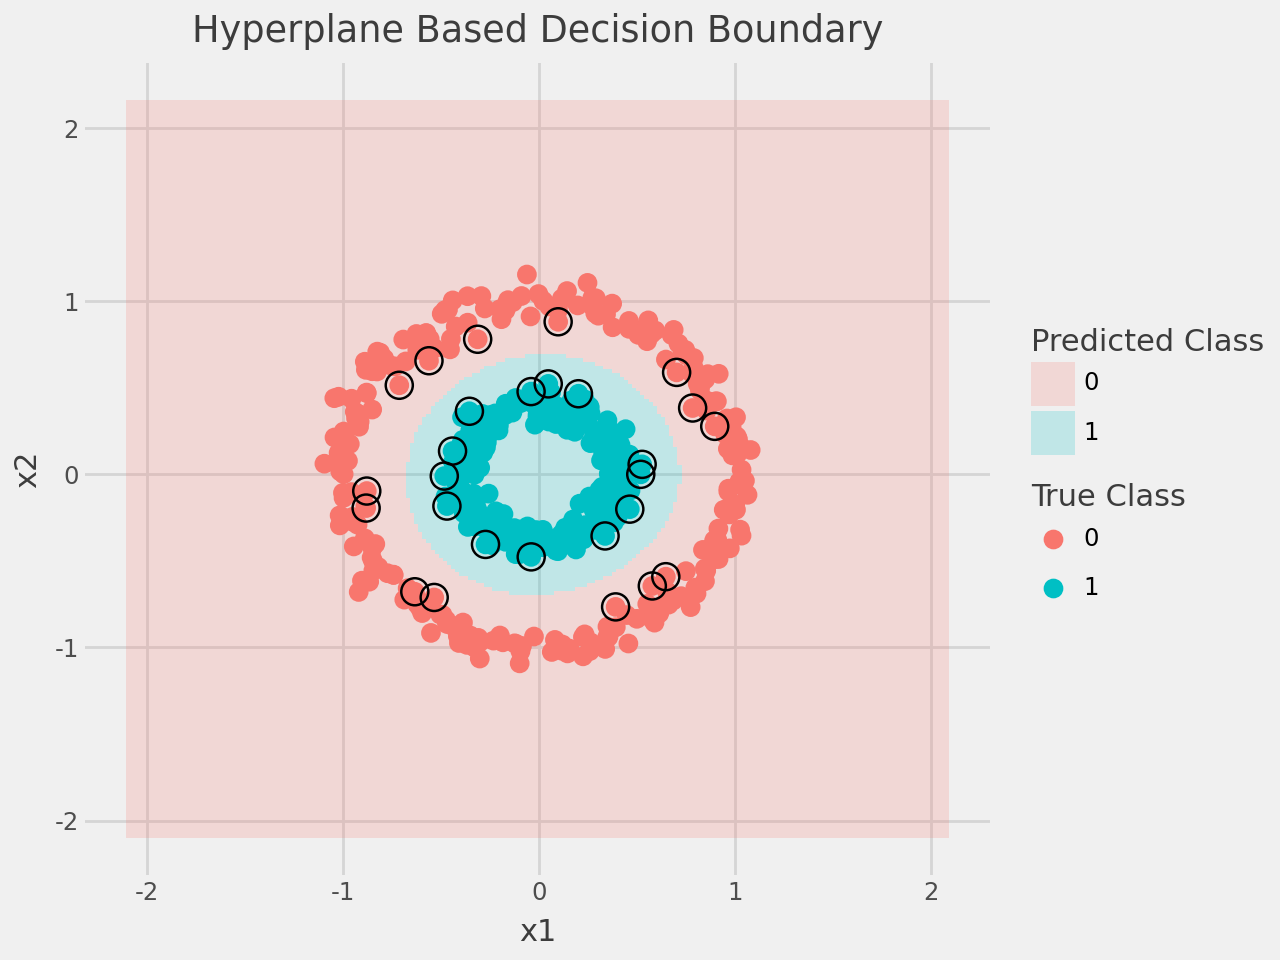

In [15]:
# initialize model
svm = SVC(kernel="rbf",gamma=1,C=1)

# generate train/test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit data to model
svm.fit(X_train,y_train)

# evaluate model
print("Training Accuracy:",svm.score(X_train,y_train))
print("Testing Accuracy:",svm.score(X_test,y_test))

# save predictions for AUC score
y_test_pred = svm.decision_function(X_test)
roc_auc = roc_auc_score(y_test,y_test_pred)
print("Test AUC score:",roc_auc)

# visualize model
show_hyperplane(svm,X,df)

Let's make our modeling workflow more efficient using Pipelines from the Scikit library

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [17]:
#prepare data
d = pd.read_csv("../datasets/svm_example_rbf.csv")
d.head()


,x1,x2,label
0,-2.356971,-4.618188,a
1,-1.257146,1.281729,a
2,-1.557418,-1.953961,a
3,-2.009731,-0.000805,a
4,-2.798693,4.154555,a


In [18]:
# relabel classes and define X and y datasets
d.columns = ['x1','x2','label']
d['label'] = d['label'].map({'a':0,'b':1})
d = d.dropna()

X = d[['x1', 'x2']]
y = d['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

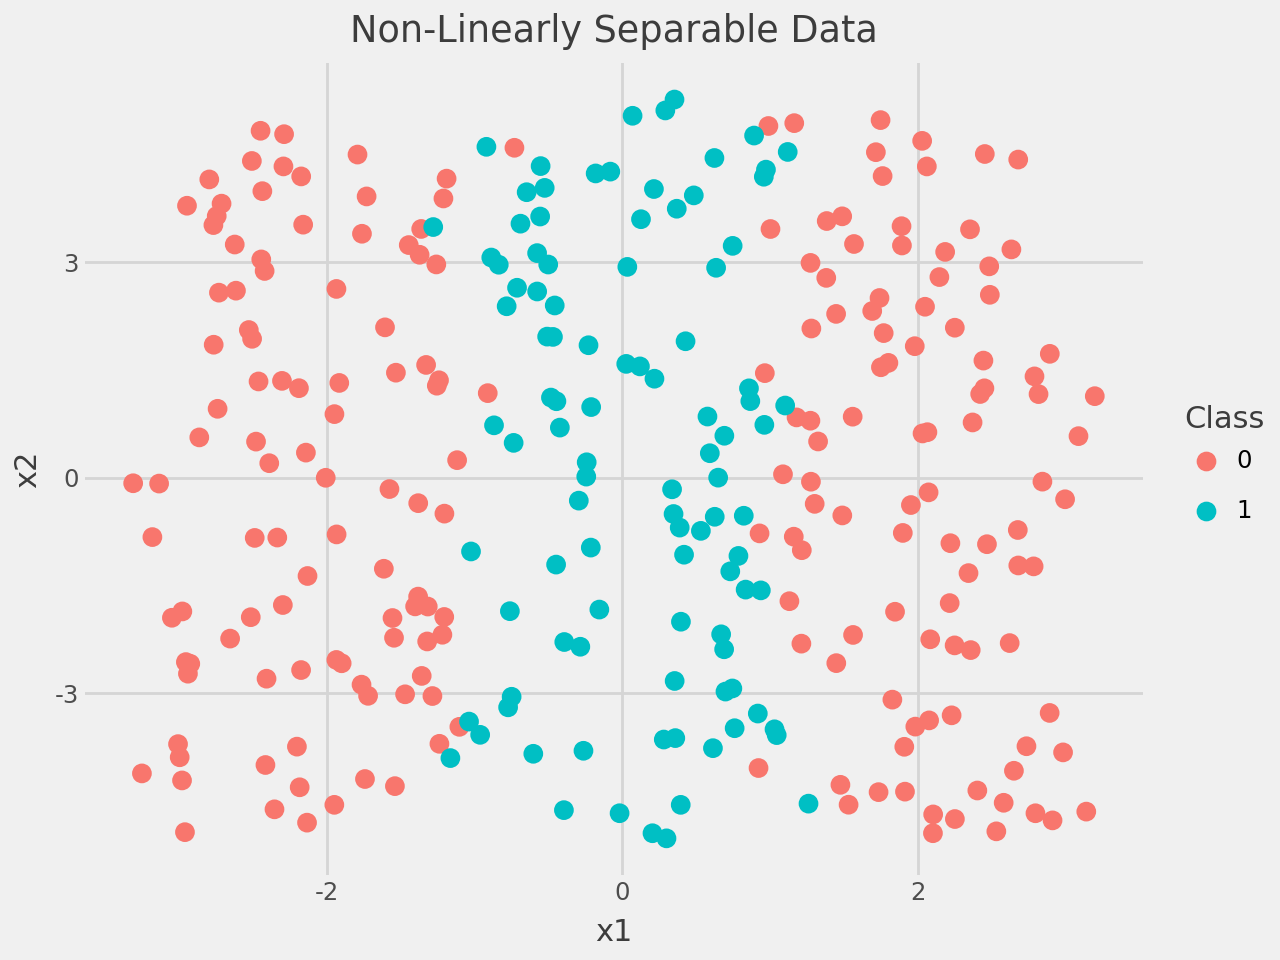

In [19]:
# visualize data
(
    ggplot(d, aes("x1", "x2", color="factor(label)")) +
    geom_point(size=3) +
    theme_538() +
    labs(title="Non-Linearly Separable Data", color="Class")
)

With Pipeline, you can create a routine of steps your data will undergo for your model

In [20]:
# Pipeline with StandardScaler and SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf',gamma=0.1,C=1))
])
pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1
,kernel,'rbf'
,degree,3
,gamma,0.1


Now, to predict, you simply need to call one function and it will handle any data preprocessing involved

In [21]:
y_train_pred = pipe.predict(X_train)
y_test_pred = pipe.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, y_train_pred))
print('Testing accuracy:', accuracy_score(y_test, y_test_pred))

Training accuracy: 0.9
Testing accuracy: 0.9


Instead of predicting a hard class label (like 0 or 1), we can also compute how far and on which side of the decision boundary each data point lies.

In [22]:
y_test_score = pipe.decision_function(X_test)
print('Test ROC AUC:', roc_auc_score(y_test, y_test_score))

Test ROC AUC: 0.978468899521531


You can always directly call a specific function within your Pipeline for use. 

In [23]:
X_scaled = pipe.named_steps['scaler'].transform(X)
data_scaled = pd.DataFrame(X_scaled, columns=['x1', 'x2'])
data_scaled['label'] = y.values

And you can call the model directly as well on scaled data. 

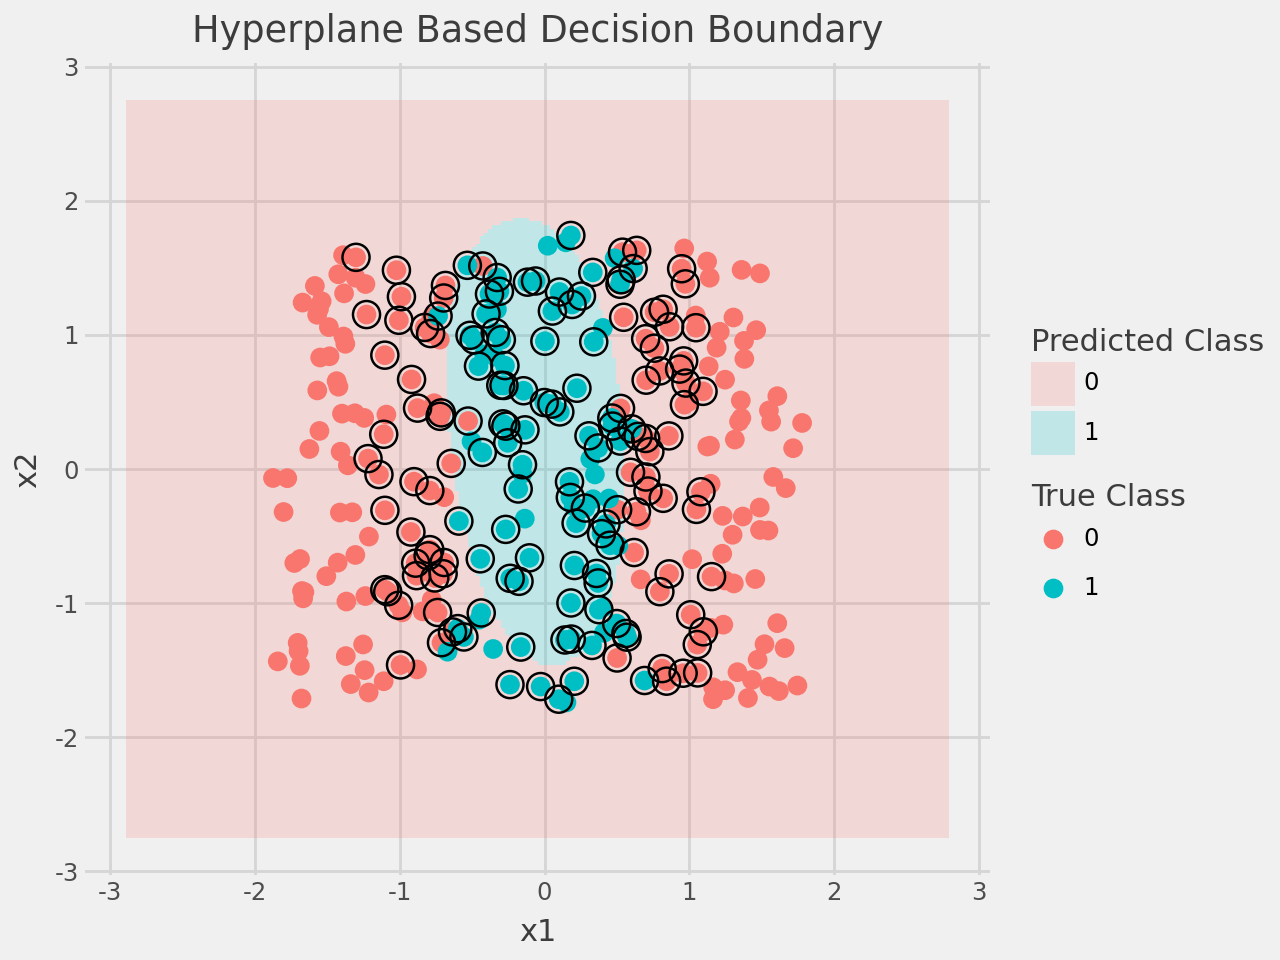

In [24]:
# visualize model (use pipeline and unscaled data)
show_hyperplane(pipe.named_steps['svc'], X_scaled, data_scaled)

Lastly, GridSearch allows you to identify the best set of hyperparameters for your model. You can pass lists of potential values for the parameters and let the algorithm train a series of models to capture the best set. 

In [25]:
from sklearn.model_selection import GridSearchCV

# prepare data
X = d[['x1', 'x2']]
y = d['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [52]:
# Pipeline with StandardScaler and SVC
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf'))
])

In [27]:
# build set of parameter values to test
param_grid = {
    'svc__gamma': [0.001, 0.01, 0.1, 1, 10, 100],
    'svc__C': [0.001, 0.01, 0.1, 0.5, 1]
}

In [28]:
# fit GridSearch with Cross Validation
grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

,estimator,Pipeline(step... gamma=0.1))])
,param_grid,"{'svc__C': [0.001, 0.01, ...], 'svc__gamma': [0.001, 0.01, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [29]:
# print the best values for the two hyperparameters
print('Best gamma:', grid.best_params_['svc__gamma'])
print('Best C:', grid.best_params_['svc__C'])

# store the best identified SVM
svm_best = grid.best_estimator_


Best gamma: 1
Best C: 1


Training accuracy: 0.9458333333333333
Testing accuracy: 0.9833333333333333
Test ROC AUC: 0.9988038277511962


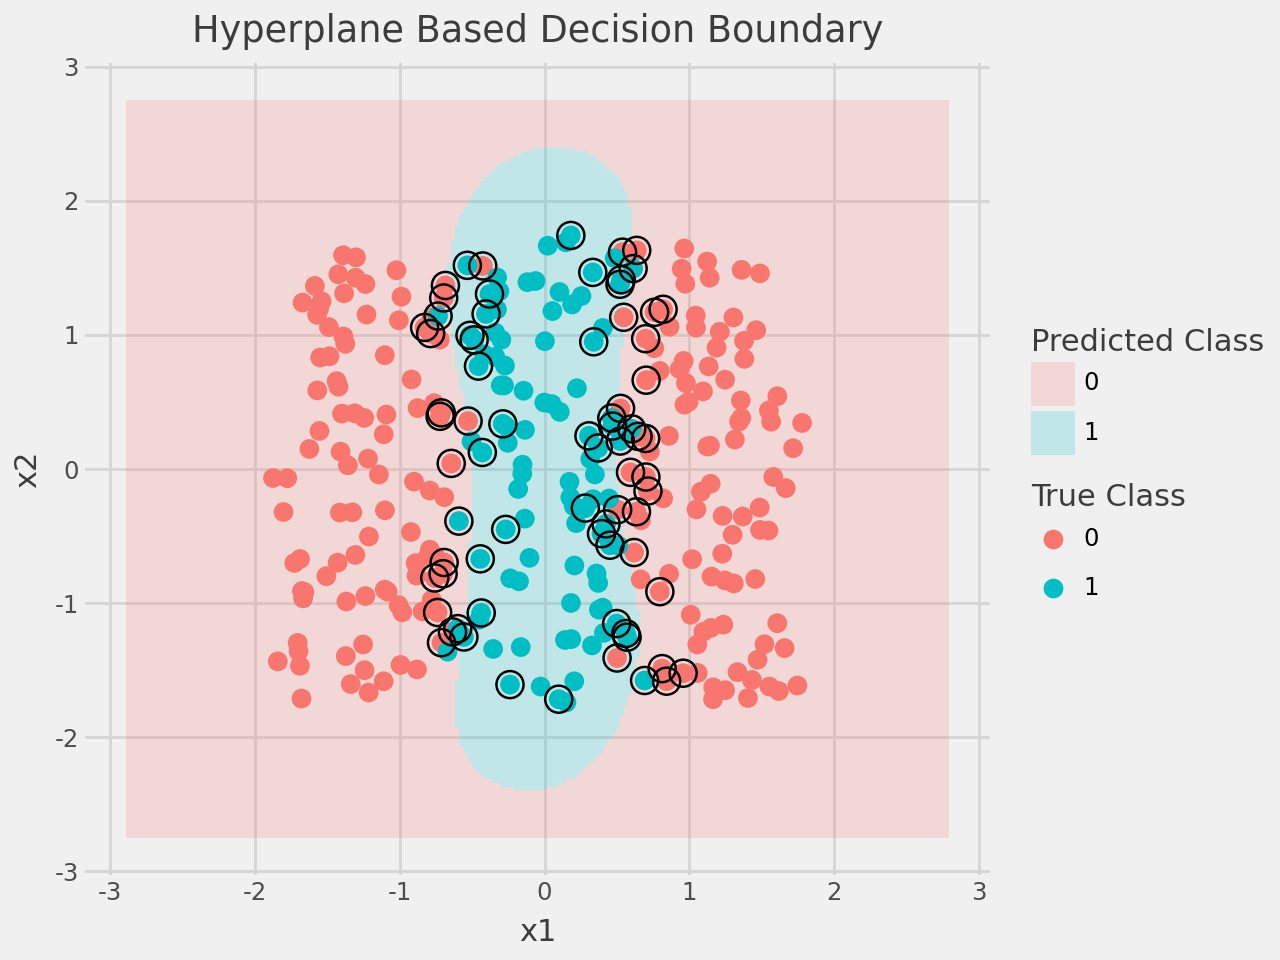

In [31]:
# predict using best model and visualize
y_train_pred = svm_best.predict(X_train)
y_test_pred = svm_best.predict(X_test)

print('Training accuracy:', accuracy_score(y_train, y_train_pred))
print('Testing accuracy:', accuracy_score(y_test, y_test_pred))

y_test_score = svm_best.decision_function(X_test)
print('Test ROC AUC:', roc_auc_score(y_test, y_test_score))

X_scaled = svm_best.named_steps['scaler'].transform(X)
data_scaled = pd.DataFrame(X_scaled, columns=['x1', 'x2'])
data_scaled['label'] = y.values

# visualize model (use pipeline and unscaled data)
show_hyperplane(svm_best.named_steps['svc'], X_scaled, data_scaled)